# ResNet-18 custom PTQ layer-by-layer analysis

This notebook measures the sensitivity of each eligible ResNet-18 weight tensor to 8-bit custom PTQ. In each experiment, **exactly one kernel is quantized** while every other model tensor remains FP32. This isolates the accuracy effect of that tensor.

The custom quantizer performs symmetric per-output-channel INT8 weight quantization and explicit dequantization for Keras evaluation. Activations remain FP32, no fake-quantization nodes are inserted, and no retraining is performed. This is a weight-sensitivity experiment, not an integer-runtime benchmark.

In [1]:
from pathlib import Path
import gc
import json
import sys
import time

import keras
import keras_hub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("Run this notebook from the project root or notebooks directory.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.quantization.custom_quantization import custom_ptq, dequantize_tensor

np.random.seed(42)
tf.random.set_seed(42)
print(f"Python: {sys.executable}")
print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {keras.__version__}")

/Users/sahil/Group Studies/Quantization-Group-Studies/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: /Users/sahil/Group Studies/Quantization-Group-Studies/.venv/bin/python
TensorFlow: 2.20.0
Keras: 3.14.1


## 1. Configuration

By default, all eligible kernels are analysed using 1,000 test images as a screening run. Set `NUM_EVALUATION_SAMPLES = None` for the final 10,000-image evaluation. To analyse specific layers, set `SELECTED_TENSOR_PATTERNS` to one or more substrings shown in the candidate table.

In [2]:
MODEL_PATH = (
    PROJECT_ROOT / "artifacts" / "resnet18_cifar10_training"
    / "resnet18_cifar10_fp32.keras"
)
OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "resnet18_ptq_layer_analysis"

NUM_BITS = 8
QUANTIZE_MIN_RANK = 2
PER_CHANNEL = True
NUM_EVALUATION_SAMPLES = None  # Use None for all 10,000 test images.
BATCH_SIZE = 32

# Examples: ["stack0_block0_1_conv"] or ["stack2", "stack3"].
# None analyses every eligible rank-2-or-higher floating tensor.
SELECTED_TENSOR_PATTERNS = None
MAX_TENSORS = None  # Optional quick debugging limit after filtering.

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Missing trained model: {MODEL_PATH}. Run notebook 06 first.")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Model: {MODEL_PATH}")
print(f"Evaluation subset: {NUM_EVALUATION_SAMPLES or 'all test images'}")

Model: /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/resnet18_cifar10_training/resnet18_cifar10_fp32.keras
Evaluation subset: all test images


## 2. Load the trained model and CIFAR-10

In [3]:
model = keras.models.load_model(MODEL_PATH, compile=False)
(_, _), (test_images, test_labels) = keras.datasets.cifar10.load_data()
test_labels = test_labels.reshape(-1).astype(np.int32)
if NUM_EVALUATION_SAMPLES is not None:
    test_images = test_images[:NUM_EVALUATION_SAMPLES]
    test_labels = test_labels[:NUM_EVALUATION_SAMPLES]

image_converter = keras_hub.layers.ResNetImageConverter(
    image_size=(224, 224),
    scale=[0.017124753831663668, 0.01750700280112045, 0.017429193899782133],
    offset=[-2.1179039301310043, -2.0357142857142856, -1.8044444444444445],
    interpolation="bicubic",
    crop_to_aspect_ratio=True,
)

def preprocess_images(images):
    return image_converter(images)

print(f"Evaluation images: {len(test_images):,}")
print(f"Model parameter tensors: {len(model.weights)}")
model.summary(expand_nested=True)

Evaluation images: 10,000
Model parameter tensors: 102


Model: "resnet18_cifar10_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ images (InputLayer)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_net_backbone                │ (None, 7, 7, 512)      │    11,186,112 │
│ (ResNetBackbone)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ input_layer (InputLayer)   │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv1_pad (ZeroPadding2D)  │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv1_conv (Conv2D)        │ (None, None, None, 64) │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv1_bn                   │ (None, None, None, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv1_relu (Activation)    │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ pool1_pad (ZeroPadding2D)  │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ pool1_pool (MaxPooling2D)  │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block0_1_conv       │ (None, None, None, 64) │        36,864 │
│ (Conv2D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block0_1_bn         │ (None, None, None, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block0_1_relu       │ (None, None, None, 64) │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block0_2_conv       │ (None, None, None, 64) │        36,864 │
│ (Conv2D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block0_2_bn         │ (None, None, None, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block0_add (Add)    │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block0_out          │ (None, None, None, 64) │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block1_1_conv       │ (None, None, None, 64) │        36,864 │
│ (Conv2D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block1_1_bn         │ (None, None, None, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ stack0_block1_1_relu       │ (None, None, None, 64) │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 11,191,242 (42.69 MB)

 Trainable params: 11,181,642 (42.65 MB)

 Non-trainable params: 9,600 (37.50 KB)

## 3. List and select quantizable tensors

Only floating tensors with rank 2 or higher are candidates. For this model, these are primarily Conv2D kernels and the final Dense kernel. Rank-1 biases and batch-normalization parameters remain FP32.

In [4]:
candidate_rows = []
for weight_index, weight in enumerate(model.weights):
    values = weight.numpy()
    if np.issubdtype(values.dtype, np.floating) and values.ndim >= QUANTIZE_MIN_RANK:
        tensor_name = getattr(weight, "path", weight.name)
        candidate_rows.append({
            "weight_index": weight_index,
            "tensor": tensor_name,
            "layer": tensor_name.rsplit("/", 1)[0],
            "rank": values.ndim,
            "shape": tuple(values.shape),
            "values": int(values.size),
            "fp32_bytes": int(values.nbytes),
        })
candidate_table = pd.DataFrame(candidate_rows)

if SELECTED_TENSOR_PATTERNS:
    normalized_patterns = [pattern.lower() for pattern in SELECTED_TENSOR_PATTERNS]
    selected_mask = candidate_table["tensor"].map(
        lambda name: any(pattern in name.lower() for pattern in normalized_patterns)
    )
    selected_candidates = candidate_table[selected_mask].copy()
else:
    selected_candidates = candidate_table.copy()
if MAX_TENSORS is not None:
    selected_candidates = selected_candidates.head(MAX_TENSORS)
if selected_candidates.empty:
    raise ValueError("No tensor matched SELECTED_TENSOR_PATTERNS. Inspect candidate_table.")

print(f"Eligible tensors: {len(candidate_table)}")
print(f"Selected for analysis: {len(selected_candidates)}")
display(candidate_table)

Eligible tensors: 21
Selected for analysis: 21


,weight_index,tensor,layer,rank,shape,values,fp32_bytes
0,0,conv1_conv/kernel,conv1_conv,4,"(7, 7, 3, 64)",9408,37632
1,5,stack0_block0_1_conv/kernel,stack0_block0_1_conv,4,"(3, 3, 64, 64)",36864,147456
2,10,stack0_block0_2_conv/kernel,stack0_block0_2_conv,4,"(3, 3, 64, 64)",36864,147456
3,15,stack0_block1_1_conv/kernel,stack0_block1_1_conv,4,"(3, 3, 64, 64)",36864,147456
4,20,stack0_block1_2_conv/kernel,stack0_block1_2_conv,4,"(3, 3, 64, 64)",36864,147456
5,25,stack1_block0_1_conv/kernel,stack1_block0_1_conv,4,"(3, 3, 64, 128)",73728,294912
6,30,stack1_block0_0_conv/kernel,stack1_block0_0_conv,4,"(1, 1, 64, 128)",8192,32768
7,31,stack1_block0_2_conv/kernel,stack1_block0_2_conv,4,"(3, 3, 128, 128)",147456,589824
8,40,stack1_block1_1_conv/kernel,stack1_block1_1_conv,4,"(3, 3, 128, 128)",147456,589824
9,45,stack1_block1_2_conv/kernel,stack1_block1_2_conv,4,"(3, 3, 128, 128)",147456,589824


## 4. Prediction and error helpers

In [5]:
def predict_keras_labels(keras_model, raw_images, batch_size=BATCH_SIZE):
    prediction_batches = []
    for start in range(0, len(raw_images), batch_size):
        batch = preprocess_images(raw_images[start:start + batch_size])
        logits = keras_model(batch, training=False).numpy()
        prediction_batches.append(np.argmax(logits, axis=1))
    return np.concatenate(prediction_batches)

def weight_error_metrics(original, reconstructed):
    original64 = np.asarray(original, dtype=np.float64)
    reconstructed64 = np.asarray(reconstructed, dtype=np.float64)
    error = original64 - reconstructed64
    mse = float(np.mean(error ** 2))
    mae = float(np.mean(np.abs(error)))
    max_abs_error = float(np.max(np.abs(error)))
    signal_power = float(np.mean(original64 ** 2))
    sqnr_db = float("inf") if mse == 0 else float(10 * np.log10(signal_power / mse))
    denominator = np.linalg.norm(original64.ravel()) * np.linalg.norm(reconstructed64.ravel())
    cosine_similarity = float(np.dot(original64.ravel(), reconstructed64.ravel()) / denominator) if denominator else 1.0
    return {
        "weight_mse": mse,
        "weight_mae": mae,
        "max_abs_weight_error": max_abs_error,
        "weight_cosine_similarity": cosine_similarity,
        "weight_sqnr_db": sqnr_db,
    }

## 5. Establish the FP32 baseline

Every layer experiment is compared against these exact predictions on the same evaluation images.

In [6]:
start = time.perf_counter()
fp32_predictions = predict_keras_labels(model, test_images)
fp32_accuracy = float(np.mean(fp32_predictions == test_labels))
baseline_seconds = time.perf_counter() - start
print(f"FP32 accuracy: {fp32_accuracy * 100:.2f}%")
print(f"FP32 evaluation time: {baseline_seconds:.2f} seconds")

FP32 accuracy: 90.47%
FP32 evaluation time: 108.21 seconds


## 6. Quantize exactly one tensor at a time

For each selected path, `custom_ptq(..., included_tensor_names={tensor_path})` returns exactly one INT8 tensor. The analysis model receives that reconstructed tensor while all remaining weights are restored from the FP32 checkpoint.

In [7]:
baseline_weights = [weight.numpy() for weight in model.weights]
analysis_model = keras.models.load_model(MODEL_PATH, compile=False)
analysis_rows = []
total = len(selected_candidates)

for run_index, candidate in enumerate(selected_candidates.itertuples(index=False), start=1):
    print(f"[{run_index:02d}/{total:02d}] Quantizing only {candidate.tensor}")
    start = time.perf_counter()
    result = custom_ptq(
        model,
        quantize_min_rank=QUANTIZE_MIN_RANK,
        per_channel=PER_CHANNEL,
        included_tensor_names={candidate.tensor},
    )["weights"]
    if len(result.tensors) != 1:
        raise RuntimeError(f"Expected one quantized tensor, received {len(result.tensors)}.")

    quantized_tensor = result.tensors[0]
    reconstructed = dequantize_tensor(quantized_tensor).astype(
        baseline_weights[candidate.weight_index].dtype
    )
    experiment_weights = baseline_weights.copy()
    experiment_weights[candidate.weight_index] = reconstructed
    analysis_model.set_weights(experiment_weights)
    predictions = predict_keras_labels(analysis_model, test_images)

    accuracy = float(np.mean(predictions == test_labels))
    disagreement = float(np.mean(predictions != fp32_predictions))
    fp32_correct = fp32_predictions == test_labels
    quantized_correct = predictions == test_labels
    scale_bytes = int(np.asarray(quantized_tensor.scale).nbytes)
    quantized_storage_bytes = int(quantized_tensor.values.nbytes + scale_bytes)
    memory_saved_bytes = int(candidate.fp32_bytes - quantized_storage_bytes)

    row = {
        "tensor": candidate.tensor,
        "layer": candidate.layer,
        "rank": candidate.rank,
        "shape": candidate.shape,
        "values": candidate.values,
        "num_bits": NUM_BITS,
        "fp32_accuracy_percent": fp32_accuracy * 100,
        "single_layer_accuracy_percent": accuracy * 100,
        "accuracy_drop_percentage_points": (fp32_accuracy - accuracy) * 100,
        "prediction_disagreement_percent": disagreement * 100,
        "fp32_correct_becomes_wrong": int(np.sum(fp32_correct & ~quantized_correct)),
        "fp32_wrong_becomes_correct": int(np.sum(~fp32_correct & quantized_correct)),
        "fp32_bytes": candidate.fp32_bytes,
        "quantized_weight_and_scale_bytes": quantized_storage_bytes,
        "memory_saved_bytes": memory_saved_bytes,
        "memory_saved_mib": memory_saved_bytes / 1024**2,
        "evaluation_seconds": time.perf_counter() - start,
    }
    row.update(weight_error_metrics(baseline_weights[candidate.weight_index], reconstructed))
    analysis_rows.append(row)
    print(
        f"    accuracy={accuracy * 100:.2f}% | "
        f"drop={(fp32_accuracy - accuracy) * 100:+.2f} pp | "
        f"disagreement={disagreement * 100:.2f}%"
    )

layer_analysis = pd.DataFrame(analysis_rows)
analysis_model.set_weights(baseline_weights)
gc.collect()
print("Layer-by-layer analysis complete.")

[01/21] Quantizing only conv1_conv/kernel
    accuracy=89.94% | drop=+0.53 pp | disagreement=3.17%
[02/21] Quantizing only stack0_block0_1_conv/kernel
    accuracy=90.52% | drop=-0.05 pp | disagreement=1.79%
[03/21] Quantizing only stack0_block0_2_conv/kernel
    accuracy=90.55% | drop=-0.08 pp | disagreement=0.69%
[04/21] Quantizing only stack0_block1_1_conv/kernel
    accuracy=90.53% | drop=-0.06 pp | disagreement=0.87%
[05/21] Quantizing only stack0_block1_2_conv/kernel
    accuracy=90.42% | drop=+0.05 pp | disagreement=0.42%
[06/21] Quantizing only stack1_block0_1_conv/kernel
    accuracy=90.66% | drop=-0.19 pp | disagreement=0.54%
[07/21] Quantizing only stack1_block0_0_conv/kernel
    accuracy=90.46% | drop=+0.01 pp | disagreement=0.34%
[08/21] Quantizing only stack1_block0_2_conv/kernel
    accuracy=90.56% | drop=-0.09 pp | disagreement=0.30%
[09/21] Quantizing only stack1_block1_1_conv/kernel
    accuracy=90.32% | drop=+0.15 pp | disagreement=0.61%
[10/21] Quantizing only stack

## 7. Rank layers by sensitivity

A large positive accuracy drop indicates a sensitive tensor. A negative drop means the single quantized tensor happened to improve this evaluation subset; confirm such cases using all 10,000 images before drawing conclusions.

In [8]:
sensitivity_table = layer_analysis.sort_values(
    ["accuracy_drop_percentage_points", "prediction_disagreement_percent"],
    ascending=False,
).reset_index(drop=True)
display_columns = [
    "tensor", "shape", "values", "single_layer_accuracy_percent",
    "accuracy_drop_percentage_points", "prediction_disagreement_percent",
    "weight_mse", "weight_sqnr_db", "memory_saved_mib",
]
display(sensitivity_table[display_columns])

,tensor,shape,values,single_layer_accuracy_percent,accuracy_drop_percentage_points,prediction_disagreement_percent,weight_mse,weight_sqnr_db,memory_saved_mib
0,conv1_conv/kernel,"(7, 7, 3, 64)",9408,89.94,0.53,3.17,0.000011,36.967736,0.026672
1,stack1_block1_1_conv/kernel,"(3, 3, 128, 128)",147456,90.32,0.15,0.61,0.000019,35.384115,0.421387
2,stack0_block1_2_conv/kernel,"(3, 3, 64, 64)",36864,90.42,0.05,0.42,0.000015,36.629194,0.105225
3,stack1_block0_0_conv/kernel,"(1, 1, 64, 128)",8192,90.46,0.01,0.34,0.000007,40.373025,0.022949
4,stack2_block1_1_conv/kernel,"(3, 3, 256, 256)",589824,90.46,0.01,0.27,0.000015,35.468370,1.686523
5,stack2_block0_2_conv/kernel,"(3, 3, 256, 256)",589824,90.46,0.01,0.24,0.000016,35.351053,1.686523
6,stack2_block1_2_conv/kernel,"(3, 3, 256, 256)",589824,90.47,0.00,0.14,0.000010,37.103562,1.686523
7,cifar10_predictions/kernel,"(512, 10)",5120,90.47,0.00,0.13,0.000003,42.298213,0.014610
8,stack3_block1_2_conv/kernel,"(3, 3, 512, 512)",2359296,90.47,0.00,0.12,0.000010,35.823364,6.748047
9,stack3_block1_1_conv/kernel,"(3, 3, 512, 512)",2359296,90.47,0.00,0.08,0.000012,35.505856,6.748047


## 8. Visualize layer response

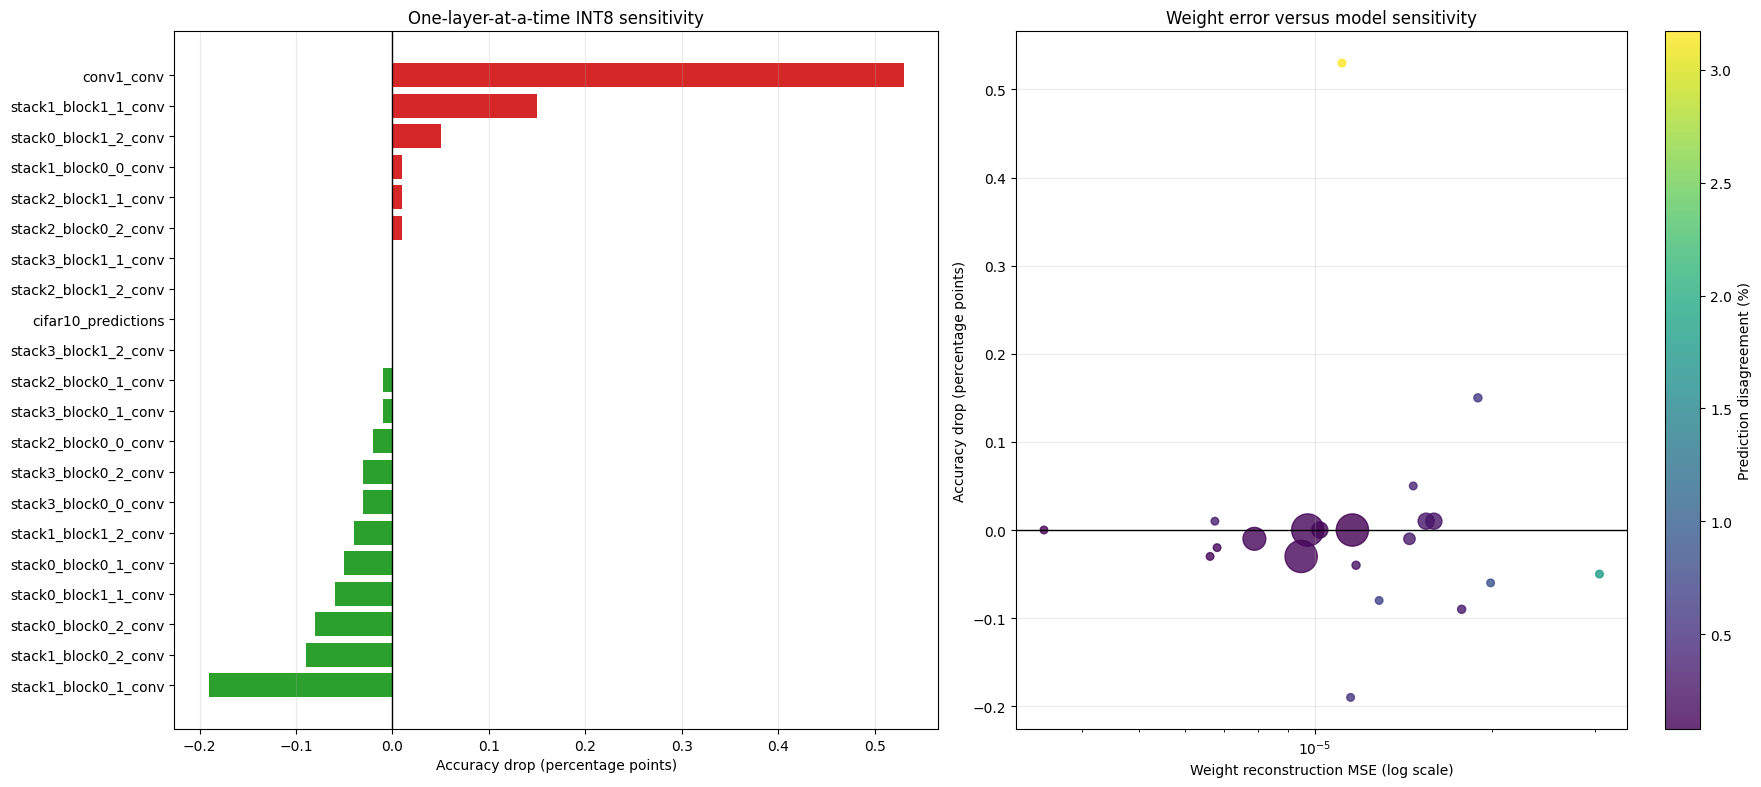

Saved plot: /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/resnet18_ptq_layer_analysis/resnet18_int8_layer_sensitivity.png


In [9]:
plot_table = sensitivity_table.sort_values("accuracy_drop_percentage_points")
figure_height = max(6, 0.38 * len(plot_table))
fig, axes = plt.subplots(1, 2, figsize=(18, figure_height))

colors = np.where(plot_table["accuracy_drop_percentage_points"] > 0, "tab:red", "tab:green")
axes[0].barh(plot_table["layer"], plot_table["accuracy_drop_percentage_points"], color=colors)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_xlabel("Accuracy drop (percentage points)")
axes[0].set_title("One-layer-at-a-time INT8 sensitivity")
axes[0].grid(axis="x", alpha=0.25)

scatter = axes[1].scatter(
    sensitivity_table["weight_mse"],
    sensitivity_table["accuracy_drop_percentage_points"],
    s=np.maximum(30, sensitivity_table["memory_saved_mib"] * 80),
    c=sensitivity_table["prediction_disagreement_percent"],
    cmap="viridis", alpha=0.8,
)
axes[1].set_xscale("log")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_xlabel("Weight reconstruction MSE (log scale)")
axes[1].set_ylabel("Accuracy drop (percentage points)")
axes[1].set_title("Weight error versus model sensitivity")
axes[1].grid(alpha=0.25)
fig.colorbar(scatter, ax=axes[1], label="Prediction disagreement (%)")
fig.tight_layout()
plot_path = OUTPUT_DIR / "resnet18_int8_layer_sensitivity.png"
fig.savefig(plot_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved plot: {plot_path}")

## 9. Save the analysis

In [10]:
results_path = OUTPUT_DIR / "resnet18_int8_layer_sensitivity.csv"
config_path = OUTPUT_DIR / "resnet18_int8_layer_sensitivity_config.json"
sensitivity_table.to_csv(results_path, index=False)
config_path.write_text(json.dumps({
    "model_path": str(MODEL_PATH),
    "num_bits": NUM_BITS,
    "per_channel": PER_CHANNEL,
    "quantize_min_rank": QUANTIZE_MIN_RANK,
    "evaluation_images": len(test_images),
    "fp32_accuracy_percent": fp32_accuracy * 100,
    "selected_tensor_patterns": SELECTED_TENSOR_PATTERNS,
    "analysed_tensors": len(sensitivity_table),
    "activations_quantized": False,
    "fake_quantization_used": False,
}, indent=2))
print(f"Saved table: {results_path}")
print(f"Saved configuration: {config_path}")

Saved table: /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/resnet18_ptq_layer_analysis/resnet18_int8_layer_sensitivity.csv
Saved configuration: /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/resnet18_ptq_layer_analysis/resnet18_int8_layer_sensitivity_config.json


## How to use the result

- **Sensitive layer:** large accuracy drop or prediction disagreement when that layer alone is quantized. Preserve it in FP32 or assign it more bits.
- **Robust layer:** near-zero accuracy drop. It is a strong quantization candidate.
- **High-value layer:** large memory saving with a small accuracy drop.
- **Specific-layer experiment:** set `SELECTED_TENSOR_PATTERNS`, restart the kernel, and run all cells. For example, `["stack0_block0_1_conv"]` quantizes only matching kernel paths.

Do not add individual accuracy drops to predict the fully quantized model's accuracy: quantization errors interact across layers. A separate cumulative experiment is required to measure those interactions.